In [16]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from prophet import Prophet

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

In [17]:
df = pd.read_csv("../data/processed/cpi_oni.csv")
df["date"] = pd.to_datetime(df["date"])

df = (
    df.sort_values("date")
      .reset_index(drop=True)
)

display(df.head())
display(df.tail())

,date,food_inflation,oni,month
0,2012-01-01,-0.21,-0.72,1
1,2012-02-01,4.45,-0.57,2
2,2012-03-01,7.09,-0.46,3
3,2012-04-01,9.32,-0.36,4
4,2012-05-01,9.70,-0.17,5


,date,food_inflation,oni,month
163,2025-08-01,-0.64,-0.28,8
164,2025-09-01,-2.33,-0.40,9
165,2025-10-01,-5.02,-0.51,10
166,2025-11-01,-3.91,-0.55,11
167,2025-12-01,-2.71,-0.54,12


In [18]:
# Prophet validation: ONI lag1 vs ONI_MA3
# Winning settings:
# changepoint_prior_scale = 0.10
# seasonality_mode = additive
# Validation year = 2023
# Final test 2024–2025 remains untouched

prophet_feature_df = df.copy()

prophet_feature_df["oni_lag1"] = (
    prophet_feature_df["oni"].shift(1)
)

prophet_feature_df["oni_ma3"] = (
    prophet_feature_df["oni"]
    .shift(1)
    .rolling(window=3)
    .mean()
)

prophet_feature_results = []

validation_start = pd.Timestamp("2023-01-01")
validation_end = pd.Timestamp("2023-12-01")

for feature in ["oni_lag1", "oni_ma3"]:

    temp_df = prophet_feature_df[
        ["date", "food_inflation", feature]
    ].copy()

    temp_df = temp_df.rename(
        columns={
            "date": "ds",
            "food_inflation": "y"
        }
    )

    temp_df = temp_df.dropna(
        subset=[feature]
    )

    model_train = temp_df[
        temp_df["ds"] < validation_start
    ].copy()

    validation = temp_df[
        (temp_df["ds"] >= validation_start) &
        (temp_df["ds"] <= validation_end)
    ].copy()

    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode="additive",
        changepoint_prior_scale=0.10,
        seasonality_prior_scale=10.0,
        interval_width=0.95
    )

    model.add_regressor(
        feature,
        mode="additive"
    )

    model.fit(model_train)

    forecast = model.predict(
        validation[["ds", feature]]
    )

    actual = validation["y"].to_numpy()
    predicted = forecast["yhat"].to_numpy()

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    smape = 100 * np.mean(
        2 * np.abs(actual - predicted)
        /
        (
            np.abs(actual)
            + np.abs(predicted)
            + 1e-8
        )
    )

    prophet_feature_results.append({
        "ONI_Feature": feature,
        "MAE": mae,
        "RMSE": rmse,
        "sMAPE": smape
    })

prophet_feature_results_df = (
    pd.DataFrame(prophet_feature_results)
    .sort_values("MAE")
    .reset_index(drop=True)
)

display(prophet_feature_results_df)

23:07:40 - cmdstanpy - INFO - Chain [1] start processing
23:07:40 - cmdstanpy - INFO - Chain [1] done processing
23:07:40 - cmdstanpy - INFO - Chain [1] start processing
23:07:40 - cmdstanpy - INFO - Chain [1] done processing


,ONI_Feature,MAE,RMSE,sMAPE
0,oni_ma3,2.158391,2.60140,32.713202
1,oni_lag1,2.335366,2.85177,35.729035


In [19]:
# Prophet validation: seasonality_prior_scale
# Winning settings:
# changepoint_prior_scale = 0.10
# seasonality_mode = additive
# ONI feature = ONI_MA3
# Validation year = 2023
# Final test 2024–2025 remains untouched

seasonality_prior_results = []

temp_df = prophet_feature_df[
    ["date", "food_inflation", "oni_ma3"]
].copy()

temp_df = temp_df.rename(
    columns={
        "date": "ds",
        "food_inflation": "y"
    }
)

temp_df = temp_df.dropna(
    subset=["oni_ma3"]
)

model_train_sp = temp_df[
    temp_df["ds"] < validation_start
].copy()

validation_sp = temp_df[
    (temp_df["ds"] >= validation_start) &
    (temp_df["ds"] <= validation_end)
].copy()

for sp in [1.0, 5.0, 10.0, 20.0]:

    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode="additive",
        changepoint_prior_scale=0.10,
        seasonality_prior_scale=sp,
        interval_width=0.95
    )

    model.add_regressor(
        "oni_ma3",
        mode="additive"
    )

    model.fit(model_train_sp)

    forecast = model.predict(
        validation_sp[["ds", "oni_ma3"]]
    )

    actual = validation_sp["y"].to_numpy()
    predicted = forecast["yhat"].to_numpy()

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    smape = 100 * np.mean(
        2 * np.abs(actual - predicted)
        /
        (
            np.abs(actual)
            + np.abs(predicted)
            + 1e-8
        )
    )

    seasonality_prior_results.append({
        "seasonality_prior_scale": sp,
        "MAE": mae,
        "RMSE": rmse,
        "sMAPE": smape
    })

seasonality_prior_results_df = (
    pd.DataFrame(seasonality_prior_results)
    .sort_values("MAE")
    .reset_index(drop=True)
)

display(seasonality_prior_results_df)

23:07:40 - cmdstanpy - INFO - Chain [1] start processing
23:07:40 - cmdstanpy - INFO - Chain [1] done processing
23:07:41 - cmdstanpy - INFO - Chain [1] start processing
23:07:41 - cmdstanpy - INFO - Chain [1] done processing
23:07:41 - cmdstanpy - INFO - Chain [1] start processing
23:07:41 - cmdstanpy - INFO - Chain [1] done processing
23:07:41 - cmdstanpy - INFO - Chain [1] start processing
23:07:41 - cmdstanpy - INFO - Chain [1] done processing


,seasonality_prior_scale,MAE,RMSE,sMAPE
0,5.0,2.119658,2.557969,32.078118
1,10.0,2.158391,2.601400,32.713202
2,1.0,2.166787,2.609143,32.837848
3,20.0,2.173729,2.618332,32.963937


In [20]:
# Prophet validation: ONI_MA3 regressor mode
# Winning settings:
# changepoint_prior_scale = 0.10
# seasonality_prior_scale = 1.0
# seasonality_mode = additive
# Validation year = 2023
# Final test 2024–2025 remains untouched

regressor_mode_results = []

for reg_mode in ["additive", "multiplicative"]:

    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode="additive",
        changepoint_prior_scale=0.10,
        seasonality_prior_scale=1.0,
        interval_width=0.95
    )

    model.add_regressor(
        "oni_ma3",
        mode=reg_mode
    )

    model.fit(model_train_sp)

    forecast = model.predict(
        validation_sp[["ds", "oni_ma3"]]
    )

    actual = validation_sp["y"].to_numpy()
    predicted = forecast["yhat"].to_numpy()

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    smape = 100 * np.mean(
        2 * np.abs(actual - predicted)
        /
        (
            np.abs(actual)
            + np.abs(predicted)
            + 1e-8
        )
    )

    regressor_mode_results.append({
        "ONI_regressor_mode": reg_mode,
        "MAE": mae,
        "RMSE": rmse,
        "sMAPE": smape
    })

regressor_mode_results_df = (
    pd.DataFrame(regressor_mode_results)
    .sort_values("MAE")
    .reset_index(drop=True)
)

display(regressor_mode_results_df)

23:07:42 - cmdstanpy - INFO - Chain [1] start processing
23:07:43 - cmdstanpy - INFO - Chain [1] done processing
23:07:43 - cmdstanpy - INFO - Chain [1] start processing
23:07:43 - cmdstanpy - INFO - Chain [1] done processing


,ONI_regressor_mode,MAE,RMSE,sMAPE
0,additive,2.166787,2.609143,32.837848
1,multiplicative,2.188560,2.610002,33.104031


In [21]:
# Final Prophet model: selected configuration
# Final unseen test: 2024–2025

final_prophet_df = df.copy()

final_prophet_df["oni_ma3"] = (
    final_prophet_df["oni"]
    .shift(1)
    .rolling(window=3)
    .mean()
)

final_prophet_df = final_prophet_df[
    ["date", "food_inflation", "oni_ma3"]
].copy()

final_prophet_df = final_prophet_df.rename(
    columns={
        "date": "ds",
        "food_inflation": "y"
    }
)

final_prophet_df = final_prophet_df.dropna(
    subset=["oni_ma3"]
)

final_prophet_train = final_prophet_df[
    final_prophet_df["ds"] < pd.Timestamp("2024-01-01")
].copy()

final_prophet_test = final_prophet_df[
    final_prophet_df["ds"] >= pd.Timestamp("2024-01-01")
].copy()

print(
    "Training:",
    final_prophet_train["ds"].min(),
    "→",
    final_prophet_train["ds"].max()
)

print(
    "Test:",
    final_prophet_test["ds"].min(),
    "→",
    final_prophet_test["ds"].max()
)

final_prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="additive",
    changepoint_prior_scale=0.10,
    seasonality_prior_scale=1.0,
    interval_width=0.95
)

final_prophet_model.add_regressor(
    "oni_ma3",
    mode="additive"
)

final_prophet_model.fit(final_prophet_train)

final_prophet_forecast = final_prophet_model.predict(
    final_prophet_test[["ds", "oni_ma3"]]
)

actual = final_prophet_test["y"].to_numpy()
predicted = final_prophet_forecast["yhat"].to_numpy()

final_prophet_mae = mean_absolute_error(
    actual,
    predicted
)

final_prophet_rmse = np.sqrt(
    mean_squared_error(
        actual,
        predicted
    )
)

final_prophet_smape = 100 * np.mean(
    2 * np.abs(actual - predicted)
    /
    (
        np.abs(actual)
        + np.abs(predicted)
        + 1e-8
    )
)

print("\nFINAL PROPHET")
print(f"MAE   : {final_prophet_mae:.4f}")
print(f"RMSE  : {final_prophet_rmse:.4f}")
print(f"sMAPE : {final_prophet_smape:.2f}%")

23:07:43 - cmdstanpy - INFO - Chain [1] start processing


Training: 2012-04-01 00:00:00 → 2023-12-01 00:00:00
Test: 2024-01-01 00:00:00 → 2025-12-01 00:00:00


23:07:43 - cmdstanpy - INFO - Chain [1] done processing



FINAL PROPHET
MAE   : 5.0169
RMSE  : 6.6850
sMAPE : 87.40%


In [22]:
# Create final Prophet predictions file

prophet_predictions = pd.DataFrame({
    "date": final_prophet_test["ds"].to_numpy(),
    "actual_food_inflation": final_prophet_test["y"].to_numpy(),
    "predicted_food_inflation": final_prophet_forecast["yhat"].to_numpy(),
    "lower_bound": final_prophet_forecast["yhat_lower"].to_numpy(),
    "upper_bound": final_prophet_forecast["yhat_upper"].to_numpy()
})

display(prophet_predictions.head(10))

print("Prediction rows:", len(prophet_predictions))
print(
    "Date range:",
    prophet_predictions["date"].min(),
    "→",
    prophet_predictions["date"].max()
)

# Save final Prophet predictions

prophet_predictions.to_csv(
    "../data/processed/prophet_predictions.csv",
    index=False
)

print("Saved: ../data/processed/prophet_predictions.csv")

,date,actual_food_inflation,predicted_food_inflation,lower_bound,upper_bound
0,2024-01-01,8.30,7.883664,2.129396,13.646616
1,2024-02-01,8.66,7.702302,1.903474,14.250690
2,2024-03-01,8.52,7.918876,2.384019,13.766104
3,2024-04-01,8.70,7.400619,1.272604,13.386090
4,2024-05-01,8.69,7.248931,0.848512,13.249051
5,2024-06-01,9.36,7.345634,1.057288,13.460231
6,2024-07-01,5.42,7.886479,1.758049,13.951194
7,2024-08-01,5.66,7.983176,2.244388,13.710543
8,2024-09-01,9.24,7.882785,1.018386,13.508789
9,2024-10-01,10.87,8.107253,1.820938,13.959050


Prediction rows: 24
Date range: 2024-01-01 00:00:00 → 2025-12-01 00:00:00
Saved: ../data/processed/prophet_predictions.csv


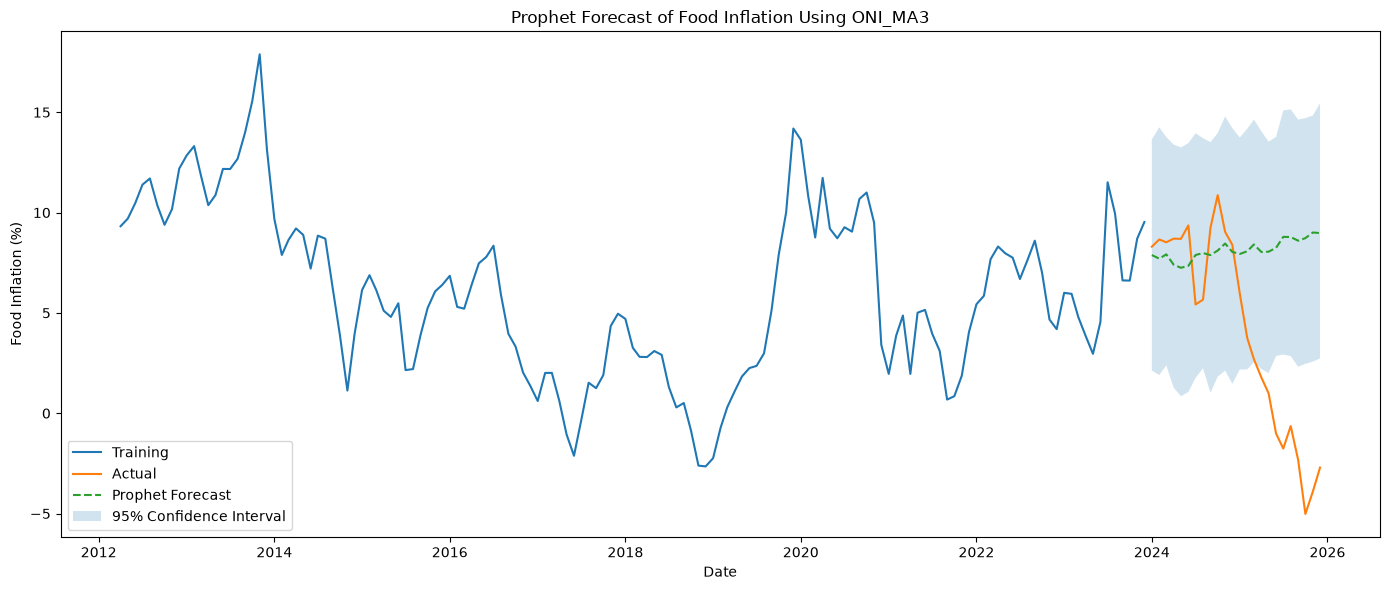

In [23]:
# Final Prophet forecast plot

plt.figure(figsize=(14, 6))

plt.plot(
    final_prophet_train["ds"],
    final_prophet_train["y"],
    label="Training"
)

plt.plot(
    final_prophet_test["ds"],
    final_prophet_test["y"],
    label="Actual"
)

plt.plot(
    final_prophet_test["ds"],
    final_prophet_forecast["yhat"],
    linestyle="--",
    label="Prophet Forecast"
)

plt.fill_between(
    final_prophet_test["ds"],
    final_prophet_forecast["yhat_lower"],
    final_prophet_forecast["yhat_upper"],
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.xlabel("Date")
plt.ylabel("Food Inflation (%)")
plt.title("Prophet Forecast of Food Inflation Using ONI_MA3")
plt.legend()
plt.tight_layout()
plt.show()

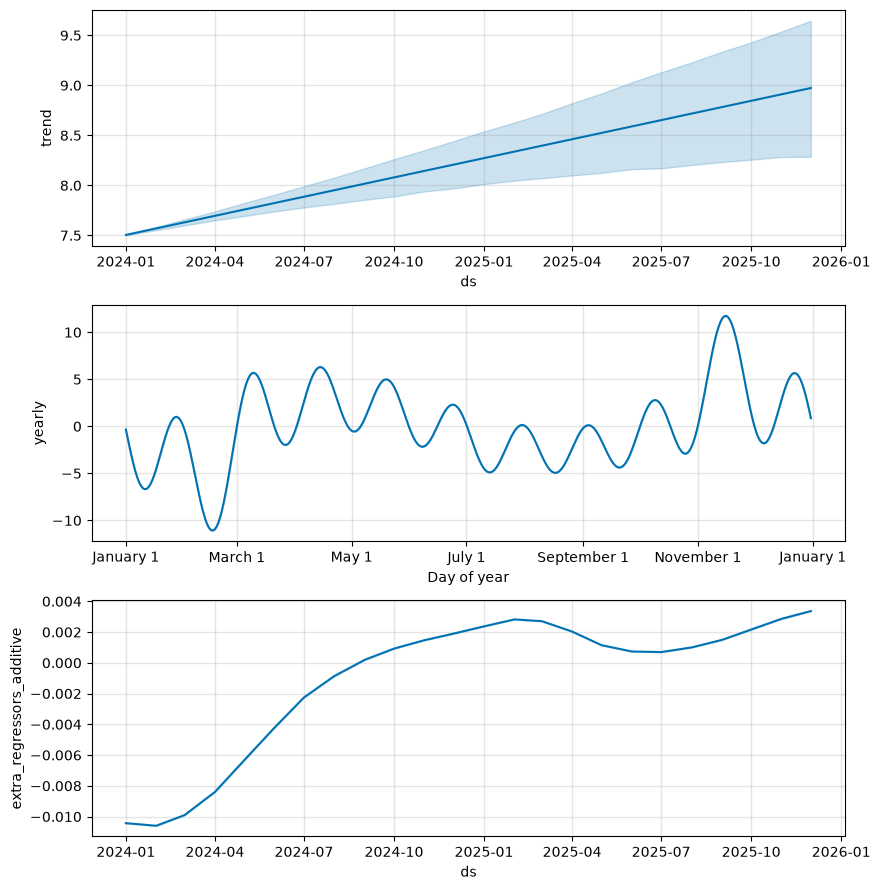

In [24]:
# Final Prophet components

fig = final_prophet_model.plot_components(
    final_prophet_forecast
)

plt.show()

In [25]:
# Final Prophet residuals

prophet_residuals = (
    final_prophet_test["y"].to_numpy()
    - final_prophet_forecast["yhat"].to_numpy()
)

print("Residual count:", len(prophet_residuals))

Residual count: 24


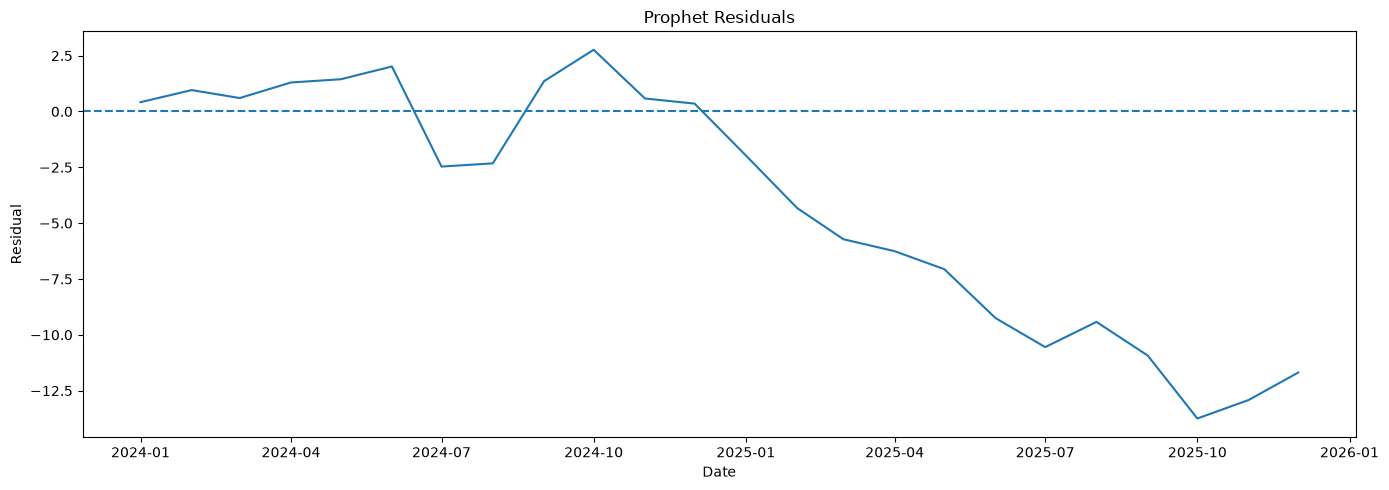

In [26]:
# Prophet residuals over time

plt.figure(figsize=(14, 5))

plt.plot(
    final_prophet_test["ds"],
    prophet_residuals
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Date")
plt.ylabel("Residual")
plt.title("Prophet Residuals")

plt.tight_layout()
plt.show()

<Figure size 1000x500 with 0 Axes>

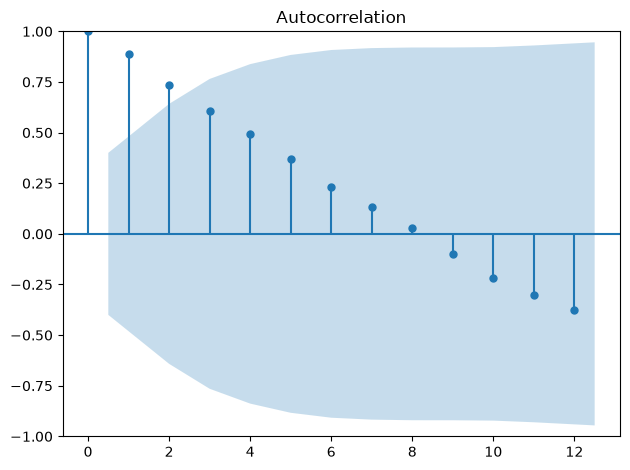

In [27]:
# Prophet residual ACF

from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(10, 5))

plot_acf(
    prophet_residuals,
    lags=12
)

plt.tight_layout()
plt.show()

In [28]:
# Ljung–Box test for residual autocorrelation

from statsmodels.stats.diagnostic import acorr_ljungbox

prophet_ljung_box = acorr_ljungbox(
    prophet_residuals,
    lags=[12],
    return_df=True
)

display(prophet_ljung_box)

,lb_stat,lb_pvalue
12,76.488561,1.920360e-11


In [29]:
# Jarque–Bera test for residual normality

from scipy.stats import jarque_bera

prophet_jb_stat, prophet_jb_pvalue = jarque_bera(
    prophet_residuals
)

print(
    "Jarque-Bera statistic:",
    prophet_jb_stat
)

print(
    "Jarque-Bera p-value:",
    prophet_jb_pvalue
)

Jarque-Bera statistic: 2.3964584904935977
Jarque-Bera p-value: 0.30172802548155564
